In [2]:
import sys
from pathlib import Path
from typing import Dict, Any

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PYTHONWARNINGS = "ignore:In 2.9.*:UserWarning:torchaudio._backend.utils,ignore:'pin_memory'.*:UserWarning:torch.utils.data.dataloader"

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "esc50" / "data")

print(f"Current directory: {current_dir}")
print(f"Project root: {project_root}")
print(f"Data root: {data_root}")

Current directory: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/notebooks/esc50
Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4
Data root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data


In [1]:

from src.models.v2.build_model import BlockConfig
from esc50_task import ESC50Task


def create_block_cfg_ctor(
    core: str,
    dropout: float,
    mlp_ratio: float,
    droppath_final: float,
    layerscale_init: float,
    residual_gain: float,
    pool: str,
    # S4-specific params
    d_state: int = 128,
    channels: int = 4,
    bidirectional: bool = True,
    mode: str = 's4d',
    dt_min: float = 0.001,
    dt_max: float = 0.1,
):
    """Create a block config constructor with the given hyperparameters."""

    def block_cfg_ctor(theta: int) -> BlockConfig:
        return BlockConfig(
            kind=core,
            # S4 parameters
            d_state=d_state,
            channels=channels,
            bidirectional=bidirectional,
            mode=mode,
            dt_min=dt_min,
            dt_max=dt_max,
            # Common parameters
            dropout=dropout,
            mlp_ratio=mlp_ratio,
            droppath_final=droppath_final,
            layerscale_init=layerscale_init,
            residual_gain=residual_gain,
            pool=pool,
        )
    return block_cfg_ctor

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


In [4]:
"""Configuration"""
import torch

args: Dict[str, Any] = {
    # data
    "data_root": data_root,
    "batch": 32,  # Reduced from 64 for MPS memory constraints
    "data_loader_kwargs": {
        "num_workers": 0,  # Critical for Mac - avoids slowdown
        "fold_val": 1,
        "feature": "melspec",
        "sample_rate": 16000,
        "n_mels": 128,
        "hop_length": 160,
        "n_fft": 512,
        "target_num_frames": 500,
        "augment": True,
        "pin_memory": False,
        "persistent_workers": False,
    },

    # training
    "epochs": 100,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": True,
    "save_dir": "./runs/esc50_s4_task",
    "warmup_epochs": 10,
    "patience": 10,
    "min_delta": 0.0,
    "early_key": "acc",  # Use accuracy for early stopping

    # model scaffold - Reduced for MPS memory
    "d_model": 256,
    "depth": 4,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.05,
    "layerscale_init": 1e-2,
    "residual_gain": 1.0,
    "pool": "mean",

    # S4-specific parameters - Optimized for MPS
    "core": "s4",
    "d_state": 64,
    "channels": 2,
    "bidirectional": False,  # Disabled to save memory
    "mode": 's4d',
    "dt_min": 0.001,
    "dt_max": 0.1,
}

args["block_cfg_ctor"] = create_block_cfg_ctor(
    core=args["core"],
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
    d_state=args["d_state"],
    channels=args["channels"],
    bidirectional=args["bidirectional"],
    mode=args["mode"],
    dt_min=args["dt_min"],
    dt_max=args["dt_max"],
)

# Device selection
if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("🚀 Using MPS (Apple Silicon)")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("🚀 Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("⚠️ Using CPU")


🚀 Using MPS (Apple Silicon)


In [5]:
import os
from src.train_utils.trainer import Trainer

task = ESC50Task()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"✅ Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ 

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


train:   0%|          | 0/50 [00:00<?, ?it/s]/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


💾 saved best model to ./runs/esc50_s4_task/best.pt
✅ new best acc 0.0175
Epoch 000/100 | train 4.0906/0.0181 | val 4.0698/0.0175 | t 37.4s/3.3s | lr 1.00e-06


...

Epoch 085/100 | train 0.1773/0.9563 | val 2.2400/0.5450 | t 43.0s/4.1s | lr 6.70e-05


Epoch 086/100 | train 0.1561/0.9669 | val 2.2466/0.5425 | t 43.6s/3.9s | lr 5.85e-05


Epoch 087/100 | train 0.1541/0.9625 | val 2.2423/0.5475 | t 47.7s/4.1s | lr 5.06e-05


Epoch 088/100 | train 0.1509/0.9619 | val 2.2294/0.5525 | t 49.7s/4.2s | lr 4.32e-05


⏹ Early stopping (patience=10, best=0.5600).
📊 Training history saved to ./runs/esc50_s4_task/history.json
✅ Done. Best acc=0.5600 @ ./runs/esc50_s4_task/best.pt


In [7]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=ESC50Task(),
)

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
✅ Loaded checkpoint from epoch 78
📊 Val metrics: {'loss': 2.1794225215911864, 'time_s': 3.8839452499996696, 'acc': 0.56}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


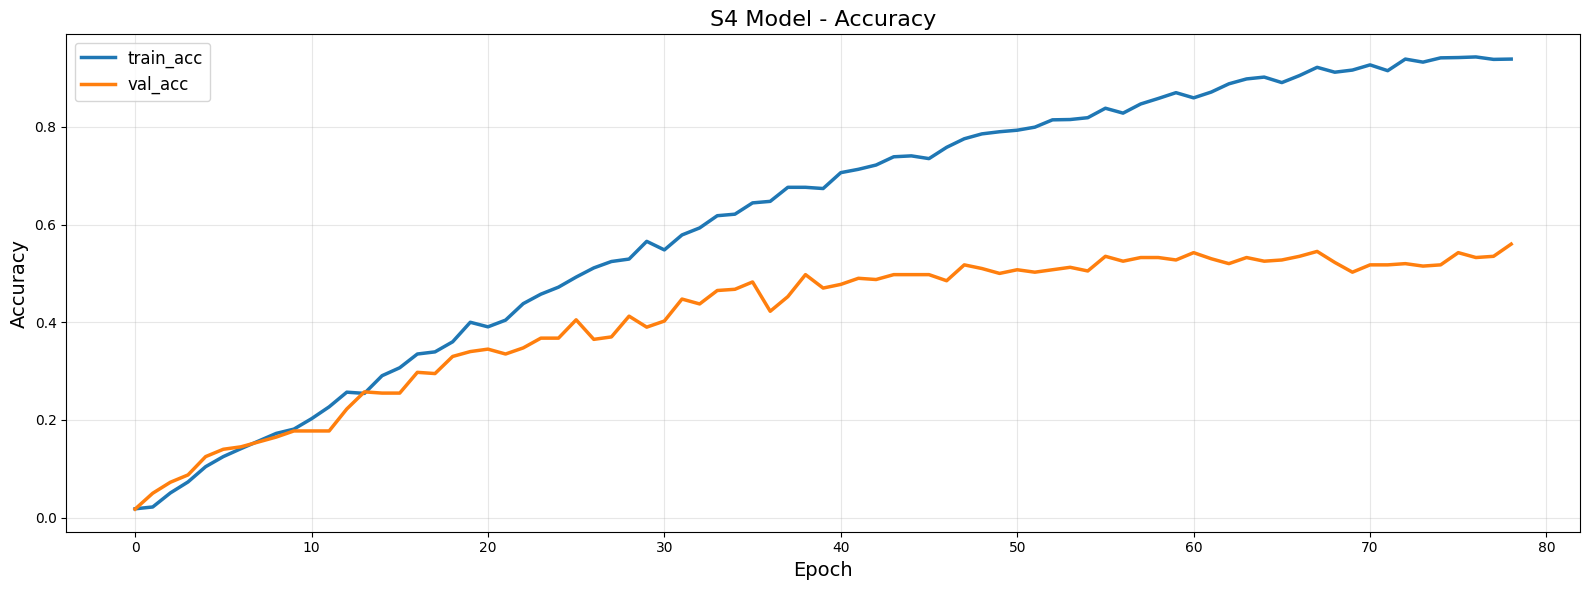

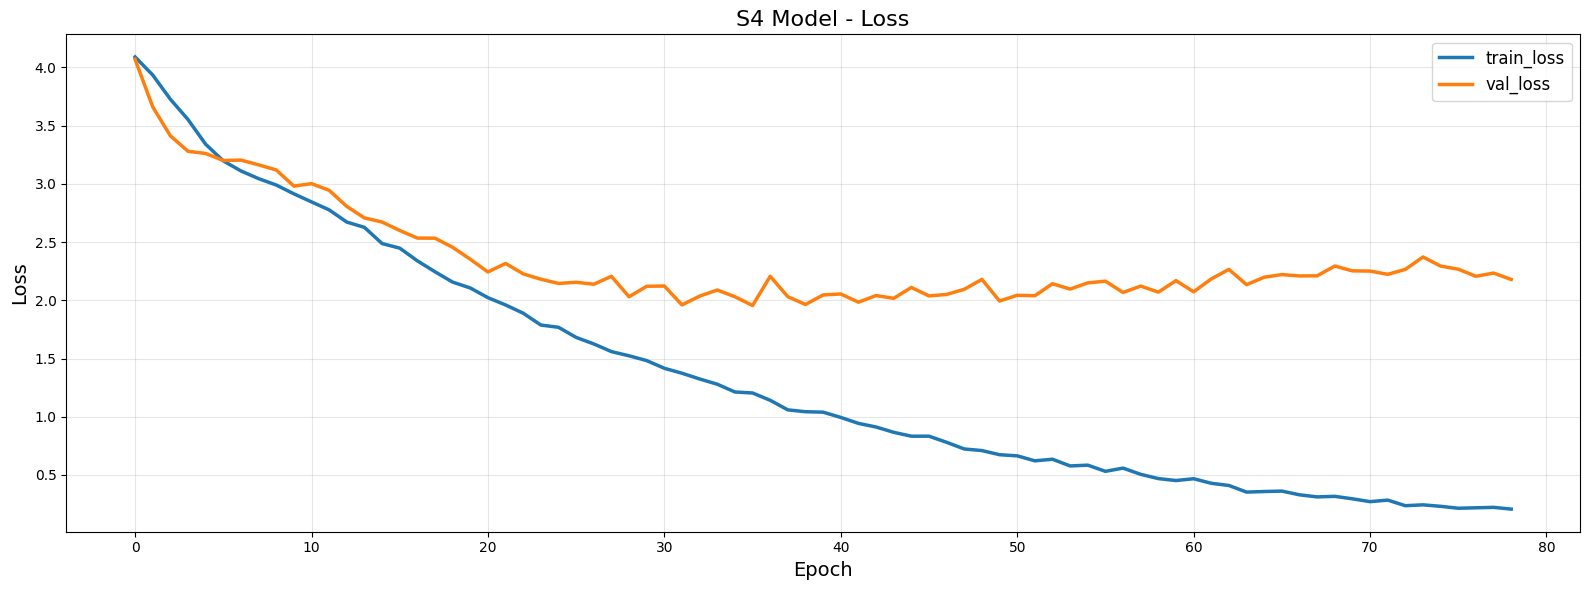

In [8]:
"""Visualize training history"""
from esc50_eval import plot_training_history

plot_training_history(trainer, model_name="S4")

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(



VALIDATION SET RESULTS
Overall accuracy: 0.5600

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_30                  : 1.000
02. class_19                  : 1.000
03. class_9                   : 1.000
04. class_34                  : 1.000
05. class_18                  : 0.875
06. class_12                  : 0.750
07. class_3                   : 0.750
08. class_42                  : 0.750
09. class_39                  : 0.750
10. class_17                  : 0.750
Bottom per-class accuracies:
01. class_40                  : 0.125
02. class_15                  : 0.250
03. class_48                  : 0.250
04. class_46                  : 0.250
05. class_7                   : 0.250
06. class_35                  : 0.250
07. class_23                  : 0.250
08. class_45                  : 0.375
09. class_41                  : 0.375
10. class_6                   : 0.375


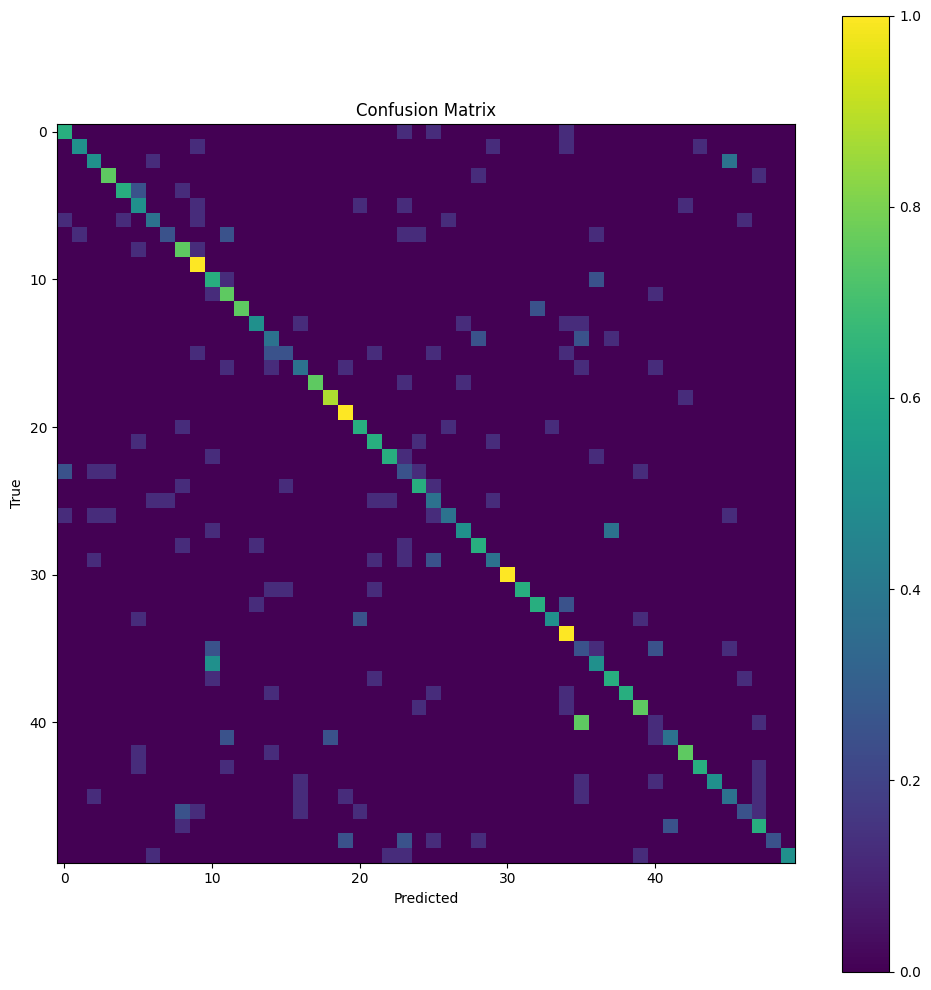

In [9]:
"""Detailed evaluation with confusion matrix"""
from esc50_eval import evaluate_best_model

evaluate_best_model(trainer, args, ESC50Task(), num_classes=50)

In [10]:
from src.utils.common import print_model_details

print_model_details(model=trainer.model)


                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: S4CoreAdapter
Number of Blocks: 4

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:              2,946,354
Trainable parameters:          2,946,354
Non-trainable parameters:              0
Model size (MB):                   11.24

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
----------------------------------------------------------------------
proj                           Linear                             33,024
blocks                         ModuleList 